<a href="https://colab.research.google.com/github/Lio72rga/Aprendizaje_Automatico-2026/blob/main/Sem_4_Logistica__Lionel_Mtz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Actividad 2 (Regresión Logística)**

**Cargar Datos**

In [1]:
import os
os.listdir('/content')

['.config', 'sample_data']

In [2]:
import os
print(os.getcwd())

/content


In [3]:
print(os.listdir())

['.config', 'sample_data']


In [6]:
import pandas as pd

df = pd.read_csv('usuarios_win_mac_lin.csv')
df.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


# **Preparación de datos**

In [ ]:
from google.colab import files

# Sube el archivo 'usuarios_win_mac_lin.csv' utilizando el botón 'Choose Files'
uploaded = files.upload()

# Puedes verificar qué archivos se han subido
for fn in uploaded.keys():
  print(f'Archivo "{fn}" subido.')

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Variables
X = df[['duracion', 'paginas', 'acciones', 'valor']]
y = df['clase']

# División
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modelo
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predicción
y_pred = model.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("Reporte:\n", classification_report(y_test, y_pred))

Accuracy: 0.6764705882352942
Matriz de confusión:
 [[13  2  1]
 [ 8  4  0]
 [ 0  0  6]]
Reporte:
               precision    recall  f1-score   support

           0       0.62      0.81      0.70        16
           1       0.67      0.33      0.44        12
           2       0.86      1.00      0.92         6

    accuracy                           0.68        34
   macro avg       0.71      0.72      0.69        34
weighted avg       0.68      0.68      0.65        34



# **Grafico Matríz de Confución**

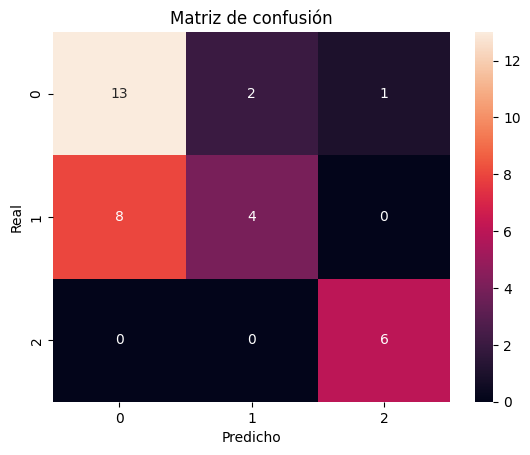

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.title("Matriz de confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

### Explicación de la Matriz de Confusión

Como vimos en clase.         Una **Matriz de Confusión** es una herramienta muy útil para evaluar el rendimiento de un modelo de clasificación, especialmente cuando se trabaja con datos desbalanceados o cuando los errores tienen diferentes costos. Muestra el número de predicciones correctas e incorrectas realizadas por el modelo, desglosadas por cada clase.

La matriz se compone típicamente de cuatro valores principales (para una clasificación binaria, aunque se extiende a multiclase):

*   **Verdaderos Positivos (VP)**: El modelo predijo correctamente la clase positiva (e.g., el usuario es 'Windows' y el modelo predijo 'Windows').
*   **Verdaderos Negativos (VN)**: El modelo predijo correctamente la clase negativa (e.g., el usuario NO es 'Windows' y el modelo predijo que NO es 'Windows').
*   **Falsos Positivos (FP)** (Error de Tipo I): El modelo predijo incorrectamente la clase positiva (e.g., el usuario NO es 'Windows' pero el modelo predijo 'Windows'). Esto también se conoce como "falsa alarma".
*   **Falsos Negativos (FN)** (Error de Tipo II): El modelo predijo incorrectamente la clase negativa (e.g., el usuario es 'Windows' pero el modelo predijo que NO es 'Windows'). Esto también se conoce como "omisión".

**Interpretación de la Matriz de Confusión:**

En este caso, tienes una clasificación multiclase (clases 0, 1 y 2). La matriz muestra:

*   La **fila** representa las **clases reales**.
*   La **columna** representa las **clases predichas**.

Por ejemplo, en esta matriz:

```
[[13  2  1]
 [ 8  4  0]
 [ 0  0  6]]
```

*   **Para la Clase 0 (fila 0):**
    *   `13` Verdaderos Positivos: 13 instancias de la clase 0 fueron correctamente clasificadas como 0.
    *   `2` Falsos Negativos: 2 instancias de la clase 0 fueron incorrectamente clasificadas como 1.
    *   `1` Falso Negativo: 1 instancia de la clase 0 fue incorrectamente clasificada como 2.

*   **Para la Clase 1 (fila 1):**
    *   `8` Falsos Negativos: 8 instancias de la clase 1 fueron incorrectamente clasificadas como 0.
    *   `4` Verdaderos Positivos: 4 instancias de la clase 1 fueron correctamente clasificadas como 1.
    *   `0` Falsos Negativos: 0 instancias de la clase 1 fueron incorrectamente clasificadas como 2.

*   **Para la Clase 2 (fila 2):**
    *   `0` Falsos Negativos: 0 instancias de la clase 2 fueron incorrectamente clasificadas como 0.
    *   `0` Falsos Negativos: 0 instancias de la clase 2 fueron incorrectamente clasificadas como 1.
    *   `6` Verdaderos Positivos: 6 instancias de la clase 2 fueron correctamente clasificadas como 2.
**La pregunta seria**

**¿Por qué es importante?**

La matriz de confusión nos permite ir más allá de la simple métrica de `Accuracy` (precisión general) y entender dónde tu modelo está cometiendo errores. Por ejemplo, puedes ver si el modelo confunde una clase con otra, lo cual es crucial para mejorar su rendimiento.

## Evaluación del modelo

El modelo obtuvo una precisión (accuracy) del 65%, lo que indica un desempeño aceptable, aunque con margen de mejora.

A partir de la matriz de confusión se observa que:
- La clase 0 (Windows) es correctamente clasificada en la mayoría de los casos.
- La clase 2 (Linux) presenta un buen nivel de predicción.
- La clase 1 (Mac) es la más difícil de predecir, con un bajo recall, lo que indica que el modelo no logra identificar correctamente muchos de estos casos.

Esto sugiere que el modelo presenta dificultades para distinguir ciertas clases, posiblemente debido a la similitud entre los datos o a la cantidad de muestras disponibles.

En general, el modelo es funcional, pero podría mejorarse mediante el uso de más datos o técnicas de optimización.

## Conclusión

En esta actividad se implementó un modelo de regresión logística para clasificar el sistema operativo de los usuarios (Windows, Mac y Linux) a partir de variables relacionadas con su comportamiento en el sitio web.

El modelo logró identificar patrones en los datos, alcanzando una precisión del 65%, lo que indica un desempeño aceptable. Sin embargo, el análisis de la matriz de confusión mostró que el modelo presenta dificultades para clasificar correctamente la clase correspondiente a usuarios de Mac, evidenciado por un bajo valor de recall.

Esto sugiere que, si bien el modelo es funcional, existen limitaciones asociadas a la calidad, cantidad o distribución de los datos. Para mejorar su rendimiento, sería recomendable trabajar con un conjunto de datos más amplio, balancear las clases y ajustar los parámetros del modelo.

En conclusión, la regresión logística resulta una herramienta útil para problemas de clasificación, permitiendo predecir categorías a partir de variables predictoras, aunque su desempeño depende en gran medida de las características del dataset utilizado.